In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
np.random.seed(12)

In [2]:
# Defining the Gaussian kernel function
def _kernel(grid):
    return np.exp(-1*(grid**2)/2)

In [3]:
# Defining some samples
Xgrid = np.linspace(0, 1, 500)
sN = np.array([0.548, 0.823, 1.0])
sP = np.array([0.0, 0.14])

In [4]:
# Defining the KDE function, using _kernel
def own_kde(_sample, bandwidth_rule):
    if bandwidth_rule=="scott":
        scottFactor = len(_sample)**(-1/5)
        bw = scottFactor * _sample.std(ddof=1)
    elif bandwidth_rule=="srot":
        q75, q25 = np.percentile(_sample, [75, 25])
        iqr = q75 - q25
        A = min(_sample.std(ddof=1), iqr/1.34)
        bw = 0.9 * A * len(_sample)**(-1/5)
        
    pde_manual = 0.
    pde_kernels = []
    for s in _sample:
        _in = (s - Xgrid) / bw
        pde_manual = pde_manual + _kernel(_in)
        pde_kernels.append(_kernel(_in) / (len(_sample)*bw*np.sqrt(2*np.pi)))

    pde_manual = pde_manual / (len(_sample)*bw*np.sqrt(2*np.pi))

    return pde_manual, pde_kernels

Text(0.5, 1.0, 'Own Scott')

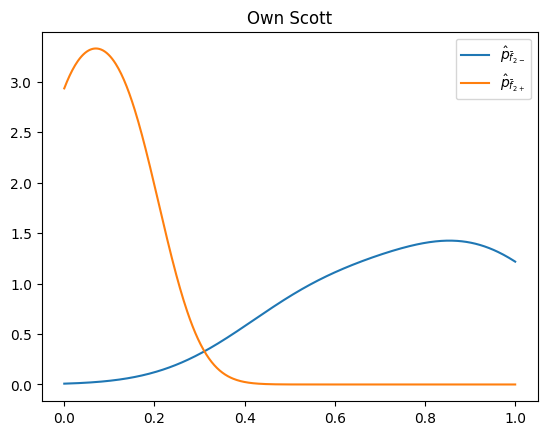

In [5]:
# Using (own) Scott
pde_ownN, pde_kernelsN = own_kde(sN, "scott")
pde_ownP, pde_kernelsP = own_kde(sP, "scott")

plt.plot(Xgrid, pde_ownN, label=r"$\hat{p}_{\bar{f}_{2-}}$")
plt.plot(Xgrid, pde_ownP, label=r"$\hat{p}_{\bar{f}_{2+}}$")
plt.legend()
plt.title("Own Scott")

Text(0.5, 1.0, 'Own Silverman')

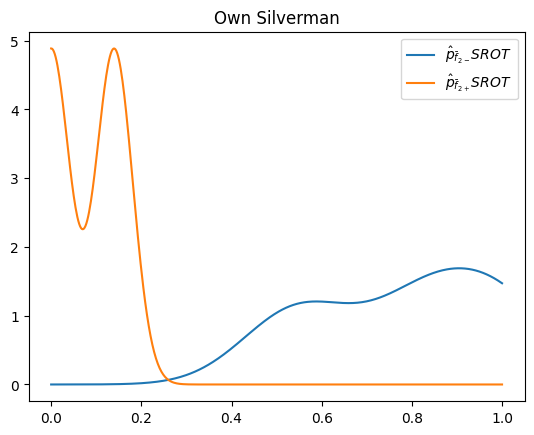

In [6]:
# Using (own) Silverman
pde_ownN_srot, pde_kernelsN_srot = own_kde(sN, "srot")
pde_ownP_srot, pde_kernelsP_srot = own_kde(sP, "srot")
plt.plot(Xgrid, pde_ownN_srot, label=r"$\hat{p}_{\bar{f}_{2-}} SROT$")
plt.plot(Xgrid, pde_ownP_srot, label=r"$\hat{p}_{\bar{f}_{2+}} SROT$")
plt.legend()
plt.title("Own Silverman")

Text(0.5, 1.0, 'SciPy + Own Silverman')

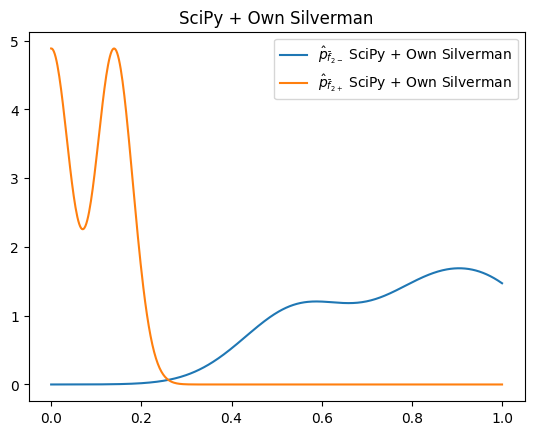

In [7]:
# Integrating (own) Silverman into SciPy's gaussian_kde
def compute_silverman_bw(_sample):
    q75, q25 = np.percentile(_sample, [75, 25])
    iqr = q75 - q25
    sampleStd = _sample.std(ddof=1)
    A = min(sampleStd, iqr/1.34)
    bw = 0.9 * A * len(_sample)**(-1/5) / sampleStd # Because scipy's Gaussian KDE will multiply it with the sample standard deviation 
    return bw

# Construct KDE for negative samples
kde_scipyN_ownSilverman = gaussian_kde(sN)
kde_scipyN_ownSilverman.set_bandwidth(bw_method=compute_silverman_bw(sN))

# Construct KDE for positive samples
kde_scipyP_ownSilverman = gaussian_kde(sP)
kde_scipyP_ownSilverman.set_bandwidth(bw_method=compute_silverman_bw(sP))

pde_scipyN_ownSilverman = np.reshape(kde_scipyN_ownSilverman(Xgrid).T, Xgrid.shape)
pde_scipyP_ownSilverman = np.reshape(kde_scipyP_ownSilverman(Xgrid).T, Xgrid.shape)

plt.plot(Xgrid, pde_scipyN_ownSilverman, label=r"$\hat{p}_{\bar{f}_{2-}}$ SciPy + Own Silverman")
plt.plot(Xgrid, pde_scipyP_ownSilverman, label=r"$\hat{p}_{\bar{f}_{2+}}$ SciPy + Own Silverman")
plt.legend()
plt.title("SciPy + Own Silverman")

Text(0.5, 1.0, "SciPy's Scott")

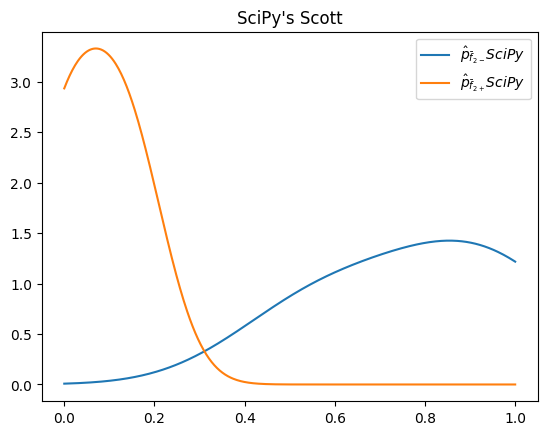

In [8]:
# Scipy's built-in KDE (Scott)
pde_scipyN = np.reshape(gaussian_kde(sN)(Xgrid).T, Xgrid.shape)
pde_scipyP = np.reshape(gaussian_kde(sP)(Xgrid).T, Xgrid.shape)
plt.plot(Xgrid, pde_scipyN, label=r"$\hat{p}_{\bar{f}_{2-}} SciPy$")
plt.plot(Xgrid, pde_scipyP, label=r"$\hat{p}_{\bar{f}_{2+}} SciPy$")
plt.legend()
plt.title("SciPy's Scott")

Text(0.5, 1.0, "SciPy's Silverman")

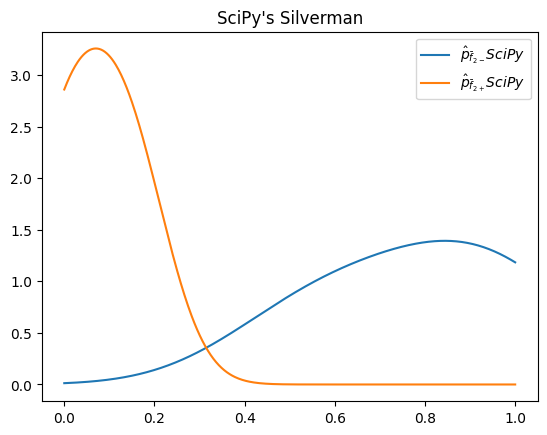

In [9]:
# Scipy's built-in KDE (Silverman)
pde_scipyN_silverman = np.reshape(gaussian_kde(sN, bw_method="silverman")(Xgrid).T, Xgrid.shape)
pde_scipyP_silverman = np.reshape(gaussian_kde(sP, bw_method="silverman")(Xgrid).T, Xgrid.shape)
plt.plot(Xgrid, pde_scipyN_silverman, label=r"$\hat{p}_{\bar{f}_{2-}} SciPy$")
plt.plot(Xgrid, pde_scipyP_silverman, label=r"$\hat{p}_{\bar{f}_{2+}} SciPy$")
plt.legend()
plt.title("SciPy's Silverman")